# Student Dropout Prediction
**Problem:** Predict whether a student will drop out of their higher education course.

**Dataset:** Predict Students Dropout and Academic Success — UCI / Kaggle

**Target Column:** `Target` → Dropout / Graduate / Enrolled → converted to Binary: 1 = Dropout | 0 = Non-Dropout

**Type:** Binary Classification

**Steps:**
1. Data Understanding
2. EDA + Visualization
3. Preprocessing
4. Model Building (Before Balancing)
5. Handling Class Imbalance (SMOTE)
6. Model Building (After Balancing)
7. Hyperparameter Tuning
8. Final Model Comparison
9. Feature Importance
10. Save Best Model

## Step 1 — Import Libraries

In [44]:
# =========================
# Core Libraries
# =========================
import numpy as np
import pandas as pd

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# Preprocessing
# =========================
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# =========================
# Handling Imbalanced Data
# =========================
from imblearn.over_sampling import SMOTE

# =========================
# Models
# =========================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier

# =========================
# Evaluation Metrics
# =========================
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

# =========================
# Hyperparameter Tuning
# =========================
from sklearn.model_selection import RandomizedSearchCV

# =========================
# Save Model
# =========================
import joblib

# =========================
# Warnings
# =========================
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully!')

All libraries imported successfully!


## Step 2 — Load Dataset

In [45]:
# Load dataset
# Rename your file to student_dropout.csv before running
df = pd.read_csv('student_dropout.csv', sep=',')

print('Dataset loaded successfully!')
print(f'Shape: {df.shape}')
df.head()

Dataset loaded successfully!
Shape: (4424, 35)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


## Step 3 — Data Understanding

In [46]:
# Dataset size and shape
print('Shape:', df.shape)
print('Size:', df.size)
print('Columns:', df.columns.tolist())

Shape: (4424, 35)
Size: 154840
Columns: ['Marital status', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Displaced', 'Educational special needs', 'Debtor', 'Tuition fees up to date', 'Gender', 'Scholarship holder', 'Age at enrollment', 'International', 'Curricular units 1st sem (credited)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (grade)', 'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (credited)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (grade)', 'Curricular units 2nd sem (without evaluations)', 'Unemployment rate', 'Inflation rate', 'GDP', 'Target']


In [47]:
# Data types
df.dtypes

Marital status                                      int64
Application mode                                    int64
Application order                                   int64
Course                                              int64
Daytime/evening attendance                          int64
Previous qualification                              int64
Nacionality                                         int64
Mother's qualification                              int64
Father's qualification                              int64
Mother's occupation                                 int64
Father's occupation                                 int64
Displaced                                           int64
Educational special needs                           int64
Debtor                                              int64
Tuition fees up to date                             int64
Gender                                              int64
Scholarship holder                                  int64
Age at enrollm

In [48]:
# Statistical summary
df.describe()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
count,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,...,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000,4424.000000
mean,1.178571,6.886980,1.727848,9.899186,0.890823,2.531420,1.254521,12.322107,16.455244,7.317812,...,0.137658,0.541817,6.232143,8.063291,4.435805,10.230206,0.150316,11.566139,1.228029,0.001969
std,0.605747,5.298964,1.313793,4.331792,0.311897,3.963707,1.748447,9.026251,11.044800,3.997828,...,0.690880,1.918546,2.195951,3.947951,3.014764,5.210808,0.753774,2.663850,1.382711,2.269935
min,1.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,7.600000,-0.800000,-4.060000
25%,1.000000,1.000000,1.000000,6.000000,1.000000,1.000000,1.000000,2.000000,3.000000,5.000000,...,0.000000,0.000000,5.000000,6.000000,2.000000,10.750000,0.000000,9.400000,0.300000,-1.700000
50%,1.000000,8.000000,1.000000,10.000000,1.000000,1.000000,1.000000,13.000000,14.000000,6.000000,...,0.000000,0.000000,6.000000,8.000000,5.000000,12.200000,0.000000,11.100000,1.400000,0.320000
75%,1.000000,12.000000,2.000000,13.000000,1.000000,1.000000,1.000000,22.000000,27.000000,10.000000,...,0.000000,0.000000,7.000000,10.000000,6.000000,13.333333,0.000000,13.900000,2.600000,1.790000
max,6.000000,18.000000,9.000000,17.000000,1.000000,17.000000,21.000000,29.000000,34.000000,32.000000,...,12.000000,19.000000,23.000000,33.000000,20.000000,18.571429,12.000000,16.200000,3.700000,3.510000


In [49]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

In [50]:
# Missing values check
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrollment                                 0
International                        

In [51]:
# Duplicate rows check
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [52]:
# Target column distribution
print('Target column distribution:')
print(df['Target'].value_counts())
print()
print(df['Target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Target column distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

Target
Graduate    49.93%
Dropout     32.12%
Enrolled    17.95%
Name: proportion, dtype: object


In [53]:
# Convert Target to Binary
# 1 = Dropout | 0 = Non-Dropout (Graduate or Enrolled)
df['Target'] = df['Target'].apply(lambda x: 1 if x == 'Dropout' else 0)

print('Target after binary conversion:')
print(df['Target'].value_counts())
print()
print(df['Target'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Target after binary conversion:
Target
0    3003
1    1421
Name: count, dtype: int64

Target
0    67.88%
1    32.12%
Name: proportion, dtype: object


## Step 4 — EDA + Visualization

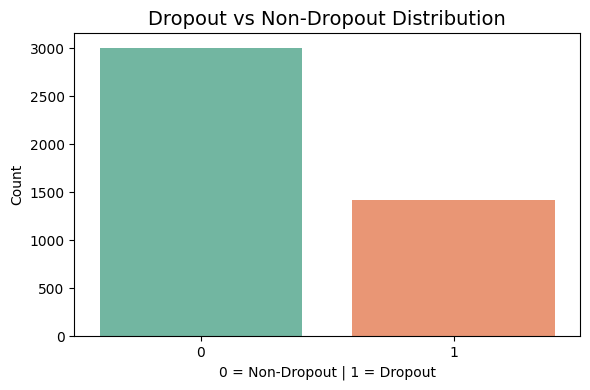

In [54]:
# -----------------------------------------------
# Plot 1: Target Class Distribution
# -----------------------------------------------
plt.figure(figsize=(6, 4))
sns.countplot(
    x='Target',
    data=df,
    palette='Set2'
)
plt.title('Dropout vs Non-Dropout Distribution', fontsize=14)
plt.xlabel('0 = Non-Dropout | 1 = Dropout')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('plot_class_distribution.png', dpi=150)
plt.show()

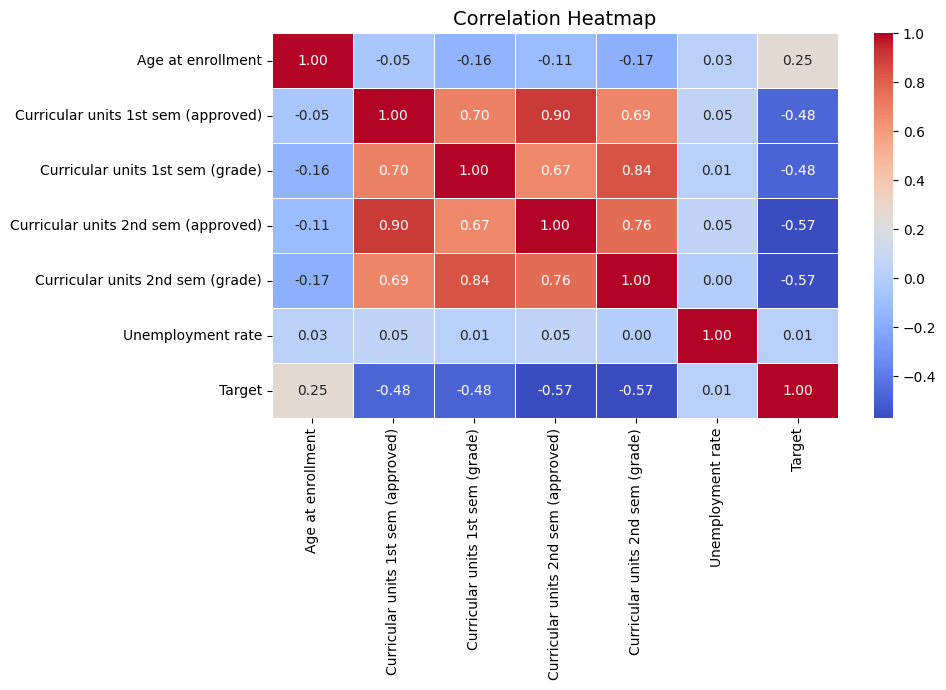

In [55]:
# -----------------------------------------------
# Plot 2: Correlation Heatmap (Numerical Columns)
# -----------------------------------------------
num_cols = [
    'Age at enrollment',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (approved)',
    'Curricular units 2nd sem (grade)',
    'Unemployment rate',
    'Target'
]

plt.figure(figsize=(10, 7))
sns.heatmap(
    df[num_cols].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5
)
plt.title('Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('plot_heatmap.png', dpi=150)
plt.show()

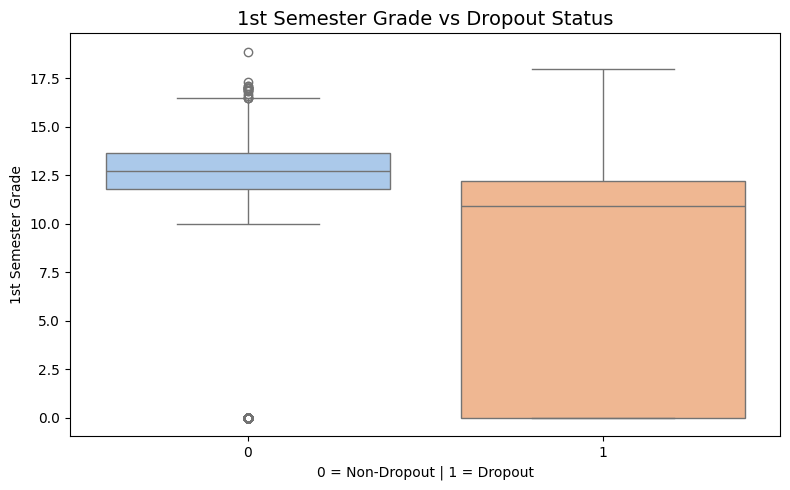

In [56]:
# -----------------------------------------------
# Plot 3: 1st Semester Grade vs Dropout
# -----------------------------------------------
plt.figure(figsize=(8, 5))
sns.boxplot(
    x='Target',
    y='Curricular units 1st sem (grade)',
    data=df,
    palette='pastel'
)
plt.title('1st Semester Grade vs Dropout Status', fontsize=14)
plt.xlabel('0 = Non-Dropout | 1 = Dropout')
plt.ylabel('1st Semester Grade')
plt.tight_layout()
plt.savefig('plot_grade_vs_dropout.png', dpi=150)
plt.show()

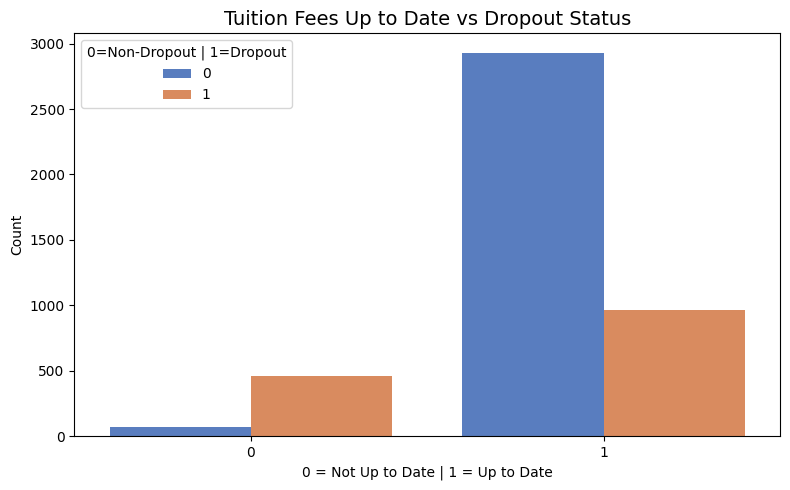

In [57]:
# -----------------------------------------------
# Plot 4: Tuition Fees vs Dropout
# -----------------------------------------------
plt.figure(figsize=(8, 5))
sns.countplot(
    x='Tuition fees up to date',
    hue='Target',
    data=df,
    palette='muted'
)
plt.title('Tuition Fees Up to Date vs Dropout Status', fontsize=14)
plt.xlabel('0 = Not Up to Date | 1 = Up to Date')
plt.ylabel('Count')
plt.legend(title='0=Non-Dropout | 1=Dropout')
plt.tight_layout()
plt.savefig('plot_tuition_vs_dropout.png', dpi=150)
plt.show()

## Step 5 — Preprocessing

In [58]:
# -----------------------------------------------
# Remove Duplicates
# -----------------------------------------------
df = df.drop_duplicates()
print('Duplicates after removal:', df.duplicated().sum())

Duplicates after removal: 0


In [59]:
# -----------------------------------------------
# Outlier Detection and Capping (IQR Method)
# -----------------------------------------------
outlier_cols = [
    'Age at enrollment',
    'Curricular units 1st sem (grade)',
    'Curricular units 2nd sem (grade)',
    'Curricular units 1st sem (approved)',
    'Curricular units 2nd sem (approved)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    LB = Q1 - 1.5 * IQR
    UB = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower=LB, upper=UB)

print('Outliers capped successfully.')

Outliers capped successfully.


In [60]:
# -----------------------------------------------
# X, Y Separation
# -----------------------------------------------
X = df.drop('Target', axis=1)
y = df['Target']

print('X shape:', X.shape)
print('y shape:', y.shape)
print('Target distribution:')
print(y.value_counts())

X shape: (4424, 34)
y shape: (4424,)
Target distribution:
Target
0    3003
1    1421
Name: count, dtype: int64


In [61]:
# -----------------------------------------------
# Scaling
# -----------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling done.')

Scaling done.


In [62]:
# -----------------------------------------------
# Train Test Split
# -----------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print('Train size:', X_train.shape)
print('Test size:', X_test.shape)

Train size: (3096, 34)
Test size: (1328, 34)


## Step 6 — Model Building (Before Balancing)

In [63]:
# -----------------------------------------------
# Helper function — evaluate model
# -----------------------------------------------
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    tr_pred = model.predict(X_tr)
    te_pred = model.predict(X_te)
    tr_acc  = accuracy_score(y_tr, tr_pred)
    te_acc  = accuracy_score(y_te, te_pred)
    return tr_acc, te_acc, model

# Model list
models = {
    'Logistic Regression' : LogisticRegression(),
    'Decision Tree'       : DecisionTreeClassifier(),
    'Random Forest'       : RandomForestClassifier(),
    'AdaBoost'            : AdaBoostClassifier(),
    'Gradient Boosting'   : GradientBoostingClassifier(),
    'XGBoost'             : XGBClassifier(),
    'KNN'                 : KNeighborsClassifier(n_neighbors=10),
    'Gaussian NB'         : GaussianNB()
}

results_before = []

for name, model in models.items():
    tr_acc, te_acc, _ = evaluate_model(name, model, X_train, X_test, y_train, y_test)
    results_before.append({'Model': name, 'Train Accuracy': round(tr_acc, 4), 'Test Accuracy': round(te_acc, 4)})
    print(f'{name} — Train: {tr_acc:.4f} | Test: {te_acc:.4f}')

df_before = pd.DataFrame(results_before)
df_before

Logistic Regression — Train: 0.8756 | Test: 0.8780
Decision Tree — Train: 1.0000 | Test: 0.7952
Random Forest — Train: 1.0000 | Test: 0.8780
AdaBoost — Train: 0.8672 | Test: 0.8712
Gradient Boosting — Train: 0.9018 | Test: 0.8742
XGBoost — Train: 1.0000 | Test: 0.8727
KNN — Train: 0.8479 | Test: 0.8434
Gaussian NB — Train: 0.8233 | Test: 0.8261


,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.8756,0.8780
1,Decision Tree,1.0000,0.7952
2,Random Forest,1.0000,0.8780
3,AdaBoost,0.8672,0.8712
4,Gradient Boosting,0.9018,0.8742
5,XGBoost,1.0000,0.8727
6,KNN,0.8479,0.8434
7,Gaussian NB,0.8233,0.8261


## Step 7 — Handle Class Imbalance (SMOTE)

In [64]:
# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE :', pd.Series(y_train_sm).value_counts().to_dict())

Before SMOTE: {0: 2102, 1: 994}
After SMOTE : {0: 2102, 1: 2102}


## Step 8 — Model Building (After Balancing)

In [65]:
results_after = []
trained_models = {}

for name, model in models.items():
    tr_acc, te_acc, fitted_model = evaluate_model(name, model, X_train_sm, X_test, y_train_sm, y_test)
    results_after.append({'Model': name, 'Train Accuracy': round(tr_acc, 4), 'Test Accuracy': round(te_acc, 4)})
    trained_models[name] = fitted_model
    print(f'{name} — Train: {tr_acc:.4f} | Test: {te_acc:.4f}')

df_after = pd.DataFrame(results_after)
df_after

Logistic Regression — Train: 0.8537 | Test: 0.8742
Decision Tree — Train: 1.0000 | Test: 0.8057
Random Forest — Train: 1.0000 | Test: 0.8840
AdaBoost — Train: 0.8744 | Test: 0.8697
Gradient Boosting — Train: 0.9206 | Test: 0.8878
XGBoost — Train: 1.0000 | Test: 0.8818
KNN — Train: 0.8792 | Test: 0.8494
Gaussian NB — Train: 0.7995 | Test: 0.8208


,Model,Train Accuracy,Test Accuracy
0,Logistic Regression,0.8537,0.8742
1,Decision Tree,1.0000,0.8057
2,Random Forest,1.0000,0.8840
3,AdaBoost,0.8744,0.8697
4,Gradient Boosting,0.9206,0.8878
5,XGBoost,1.0000,0.8818
6,KNN,0.8792,0.8494
7,Gaussian NB,0.7995,0.8208


In [66]:
# -----------------------------------------------
# Before vs After Balancing Comparison
# -----------------------------------------------
comparison = pd.DataFrame({
    'Model'                  : df_before['Model'],
    'Test Acc (Before SMOTE)': df_before['Test Accuracy'],
    'Test Acc (After SMOTE)' : df_after['Test Accuracy']
})
comparison

,Model,Test Acc (Before SMOTE),Test Acc (After SMOTE)
0,Logistic Regression,0.8780,0.8742
1,Decision Tree,0.7952,0.8057
2,Random Forest,0.8780,0.8840
3,AdaBoost,0.8712,0.8697
4,Gradient Boosting,0.8742,0.8878
5,XGBoost,0.8727,0.8818
6,KNN,0.8434,0.8494
7,Gaussian NB,0.8261,0.8208


## Step 9 — Hyperparameter Tuning (RandomizedSearchCV)

In [67]:
# -----------------------------------------------
# Random Forest Tuning
# -----------------------------------------------
rf_params = {
    'n_estimators'     : [100, 200, 300],
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(),
    param_distributions=rf_params,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
rf_search.fit(X_train_sm, y_train_sm)

print('Best RF Params:', rf_search.best_params_)
print('Best RF CV Score:', round(rf_search.best_score_, 4))

Best RF Params: {'n_estimators': 100, 'min_samples_split': 2, 'max_depth': None, 'criterion': 'gini'}
Best RF CV Score: 0.9072


In [68]:
# -----------------------------------------------
# XGBoost Tuning
# -----------------------------------------------
xgb_params = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample'    : [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(),
    param_distributions=xgb_params,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
xgb_search.fit(X_train_sm, y_train_sm)

print('Best XGB Params:', xgb_search.best_params_)
print('Best XGB CV Score:', round(xgb_search.best_score_, 4))

Best XGB Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}
Best XGB CV Score: 0.8987


In [69]:
# -----------------------------------------------
# Gradient Boosting Tuning
# -----------------------------------------------
gb_params = {
    'n_estimators' : [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth'    : [3, 5, 7],
    'subsample'    : [0.6, 0.8, 1.0]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(),
    param_distributions=gb_params,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
gb_search.fit(X_train_sm, y_train_sm)

print('Best GB Params:', gb_search.best_params_)
print('Best GB CV Score:', round(gb_search.best_score_, 4))

Best GB Params: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.2}
Best GB CV Score: 0.9003


## Step 10 — Final Model Comparison (After Tuning)

In [70]:
# Best tuned models
best_rf  = rf_search.best_estimator_
best_xgb = xgb_search.best_estimator_
best_gb  = gb_search.best_estimator_

tuned_models = {
    'Random Forest (Tuned)'     : best_rf,
    'XGBoost (Tuned)'           : best_xgb,
    'Gradient Boosting (Tuned)' : best_gb
}

tuning_results = []

for name, model in tuned_models.items():
    te_pred = model.predict(X_test)
    te_acc  = accuracy_score(y_test, te_pred)
    roc     = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    tuning_results.append({
        'Model'        : name,
        'Test Accuracy': round(te_acc, 4),
        'ROC-AUC'      : round(roc, 4)
    })
    print(f'{name} — Test Acc: {te_acc:.4f} | ROC-AUC: {roc:.4f}')

pd.DataFrame(tuning_results)

Random Forest (Tuned) — Test Acc: 0.8765 | ROC-AUC: 0.9322
XGBoost (Tuned) — Test Acc: 0.8758 | ROC-AUC: 0.9287
Gradient Boosting (Tuned) — Test Acc: 0.8682 | ROC-AUC: 0.9230


,Model,Test Accuracy,ROC-AUC
0,Random Forest (Tuned),0.8765,0.9322
1,XGBoost (Tuned),0.8758,0.9287
2,Gradient Boosting (Tuned),0.8682,0.9230


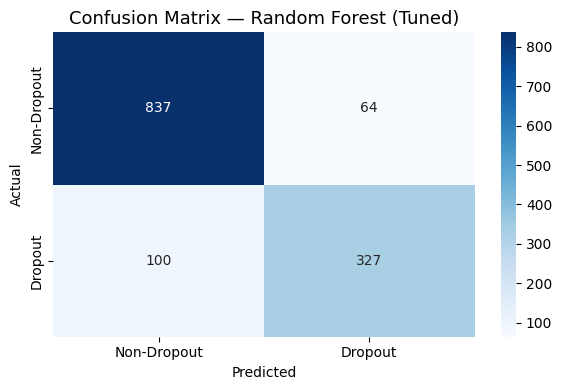

              precision    recall  f1-score   support

 Non-Dropout       0.89      0.93      0.91       901
     Dropout       0.84      0.77      0.80       427

    accuracy                           0.88      1328
   macro avg       0.86      0.85      0.86      1328
weighted avg       0.87      0.88      0.87      1328



In [71]:
# -----------------------------------------------
# Confusion Matrix — Best Model (Random Forest (Tuned)
# -----------------------------------------------
rf_pred = best_rf.predict(X_test)
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Dropout', 'Dropout'],
    yticklabels=['Non-Dropout', 'Dropout']
)
plt.title('Confusion Matrix — Random Forest (Tuned)', fontsize=13)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_test, rf_pred, target_names=['Non-Dropout', 'Dropout']))

## Step 11 — Feature Importance

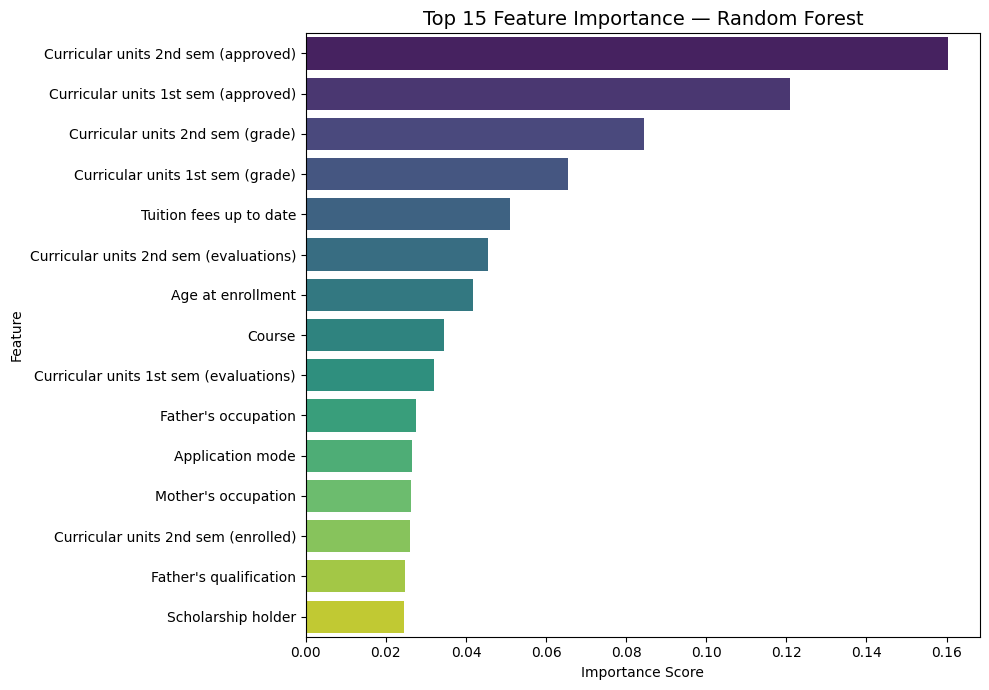

In [72]:
# Feature importance from best Random Forest model
feature_names = X.columns

importances = pd.Series(
    best_rf.feature_importances_,
    index=feature_names
).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
sns.barplot(x=importances.values, y=importances.index, palette='viridis')
plt.title('Top 15 Feature Importance — Random Forest', fontsize=14)
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()

## Step 12 — Save Best Model

In [73]:
# Save best model and scaler
joblib.dump(best_rf, 'student_dropout_model.pkl')
joblib.dump(scaler,  'student_dropout_scaler.pkl')

print('Model saved: student_dropout_model.pkl')
print('Scaler saved: student_dropout_scaler.pkl')

Model saved: student_dropout_model.pkl
Scaler saved: student_dropout_scaler.pkl


## Summary

| Step | What was done |
|------|---------------|
| Data Understanding | Shape, dtypes, missing values, duplicates |
| Target Conversion | 3-class → Binary (Dropout vs Non-Dropout) |
| EDA | Heatmap, boxplots, countplots |
| Preprocessing | Remove duplicates, cap outliers, scale |
| Model Building | 8 models — before and after SMOTE |
| Hyperparameter Tuning | RandomizedSearchCV on RF, XGBoost, GradientBoosting |
| Best Model | Random Forest (Tuned) |
| Key Metric | Accuracy + ROC-AUC |
| Saved | Model (.pkl) + Scaler (.pkl) |

In [75]:
# -----------------------------------------------
# How to Run Streamlit App
# -----------------------------------------------
print("=" * 50)
print("MODEL AND SCALER SAVED SUCCESSFULLY")
print("=" * 50)
print()
print("Files saved:")
print("  - student_dropout_model.pkl")
print("  - student_dropout_scaler.pkl")
print()
print("To run the Streamlit app:")
print("  1. Open VS Code terminal")
print("  2. Navigate to project folder")
print("  3. Run: streamlit run app.py")
print()
print("App will open at: http://localhost:8501")
print("=" * 50)

MODEL AND SCALER SAVED SUCCESSFULLY

Files saved:
  - student_dropout_model.pkl
  - student_dropout_scaler.pkl

To run the Streamlit app:
  1. Open VS Code terminal
  2. Navigate to project folder
  3. Run: streamlit run app.py

App will open at: http://localhost:8501
